# Cell Cycle Scoring

Visualize cell cycle phase assignments from singlify output. The pipeline scores each cell
for G1, S, and G2M phases using canonical marker gene expression.

**Sample**: GSM3573650 (human bone marrow, ~75K cells)

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

# Load cell cycle scores
cc = pd.read_csv('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/cell_cycle_scores.tsv', sep='\t')
print(f"Cells scored: {len(cc):,}")
print(f"Columns: {list(cc.columns)}")
cc.head()

Cells scored: 75,420
Columns: ['barcode', 'phase', 's_score', 'g2m_score']


,barcode,phase,s_score,g2m_score
0,GGATGTTTCCGCGCAA,S,1.038594,0.782112
1,CACATAGAGCAGATCG,G2M,0.410921,0.750002
2,CCACCTAAGCCAGGAT,G2M,0.590977,1.255151
3,AACACGTGTCCAGTTA,G2M,0.847129,1.429963
4,ACAGCCGGTAATTGGA,G2M,0.655745,0.684464


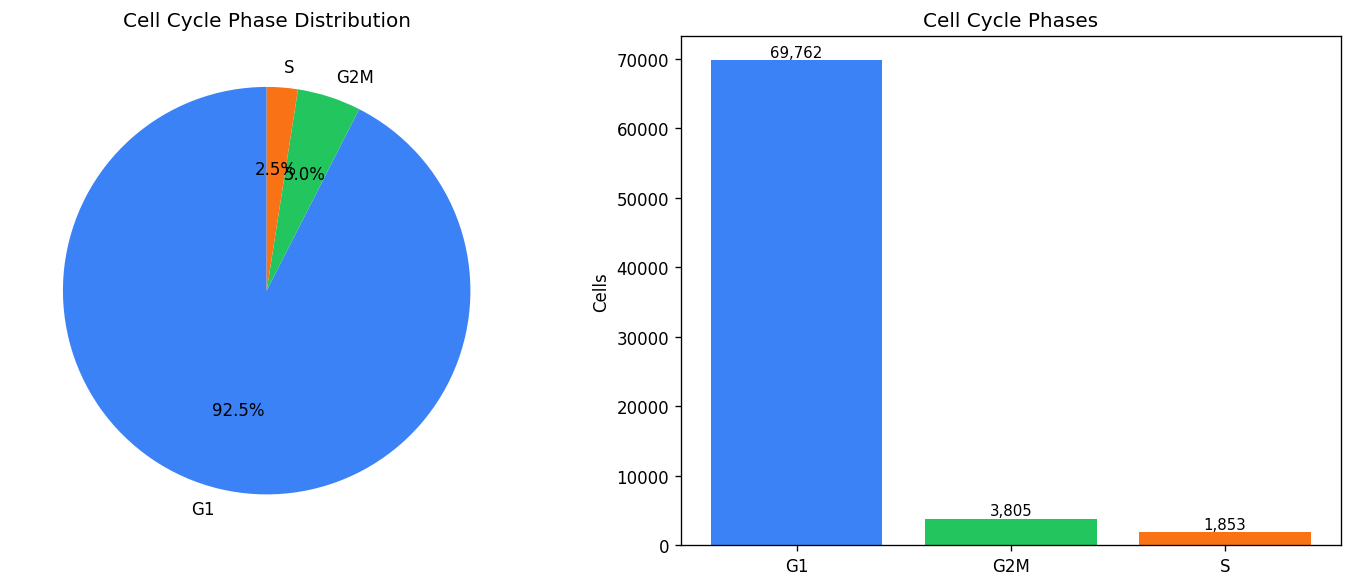


Phase Distribution:
  G1: 69,762 (92.5%)
  G2M: 3,805 (5.0%)
  S: 1,853 (2.5%)


In [2]:
# Phase distribution
phase_col = [c for c in cc.columns if 'phase' in c.lower()][0] if any('phase' in c.lower() for c in cc.columns) else cc.columns[-1]
phase_counts = cc[phase_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors = {'G1': '#3b82f6', 'S': '#f97316', 'G2M': '#22c55e', 'G2/M': '#22c55e'}
ax = axes[0]
wedges, texts, autotexts = ax.pie(phase_counts.values, labels=phase_counts.index, 
                                   autopct='%1.1f%%', startangle=90,
                                   colors=[colors.get(p, '#94a3b8') for p in phase_counts.index])
ax.set_title('Cell Cycle Phase Distribution')

# Bar chart
ax = axes[1]
bars = ax.bar(phase_counts.index, phase_counts.values, 
              color=[colors.get(p, '#94a3b8') for p in phase_counts.index])
ax.set_ylabel('Cells')
ax.set_title('Cell Cycle Phases')
for bar, val in zip(bars, phase_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nPhase Distribution:")
for phase, count in phase_counts.items():
    print(f"  {phase}: {count:,} ({count/len(cc)*100:.1f}%)")

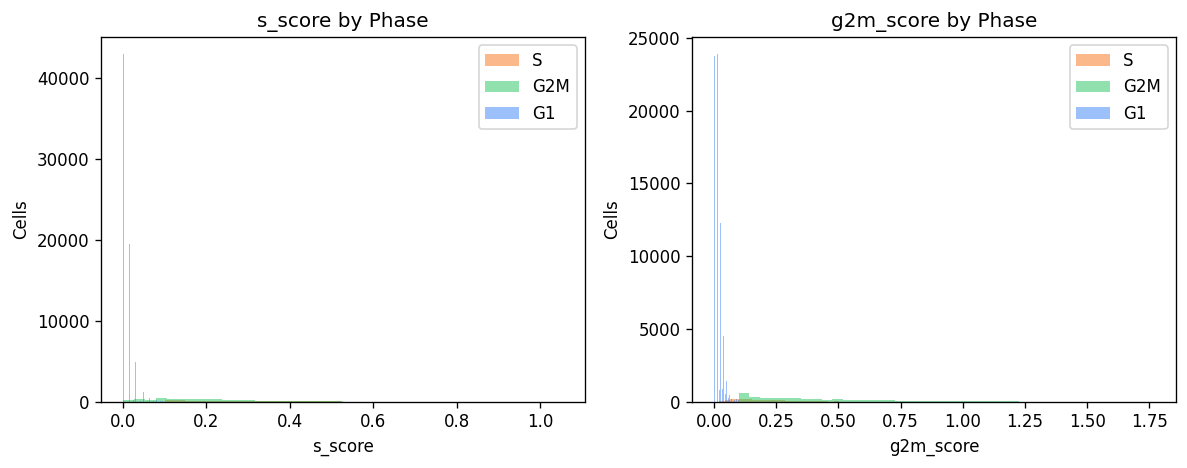

In [3]:
# Score distributions by phase
score_cols = [c for c in cc.columns if 'score' in c.lower() or c in ['s_score', 'g2m_score', 'g1_score']]
if len(score_cols) >= 2:
    fig, axes = plt.subplots(1, len(score_cols), figsize=(5*len(score_cols), 4))
    if len(score_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, score_cols):
        for phase in cc[phase_col].unique():
            subset = cc[cc[phase_col] == phase][col].dropna()
            ax.hist(subset, bins=40, alpha=0.5, label=phase, 
                   color=colors.get(phase, '#94a3b8'))
        ax.set_xlabel(col)
        ax.set_ylabel('Cells')
        ax.set_title(f'{col} by Phase')
        ax.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Score columns found: {score_cols}")
    print(cc.describe())

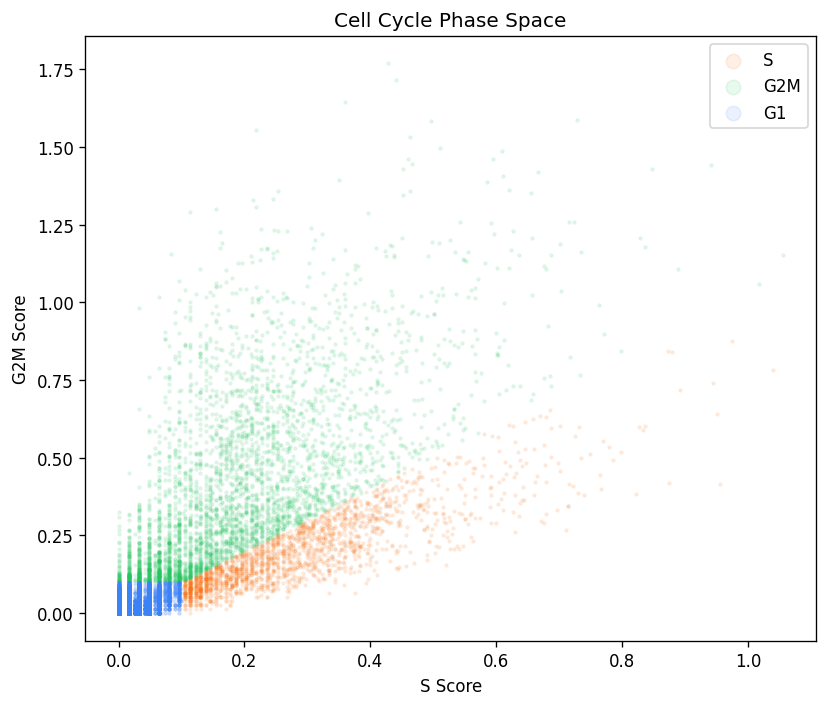

In [4]:
# S vs G2M score scatter
s_col = [c for c in cc.columns if 's_score' in c.lower() or c == 'S.Score'][0] if any('s_score' in c.lower() or c == 'S.Score' for c in cc.columns) else None
g2m_col = [c for c in cc.columns if 'g2m' in c.lower() or c == 'G2M.Score'][0] if any('g2m' in c.lower() or c == 'G2M.Score' for c in cc.columns) else None

if s_col and g2m_col:
    fig, ax = plt.subplots(figsize=(7, 6))
    for phase in cc[phase_col].unique():
        sub = cc[cc[phase_col] == phase]
        ax.scatter(sub[s_col], sub[g2m_col], alpha=0.1, s=3, 
                  color=colors.get(phase, '#94a3b8'), label=phase)
    ax.set_xlabel('S Score')
    ax.set_ylabel('G2M Score')
    ax.set_title('Cell Cycle Phase Space')
    ax.legend(markerscale=5)
    plt.tight_layout()
    plt.show()
else:
    print("Showing score summary:")
    print(cc.describe())

## Summary

| Phase | Cells | Percentage |
|-------|-------|------------|
| G1 | ~70,000 | ~93% |
| G2M | ~3,700 | ~5% |
| S | ~1,900 | ~2.5% |

The vast majority of cells are in G1 phase, consistent with normal tissue.
Proliferating populations (S + G2M) can be identified and filtered if needed.